In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\bank.csv")
print(df)

       age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campaign  pdays  previous poutcome  \

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

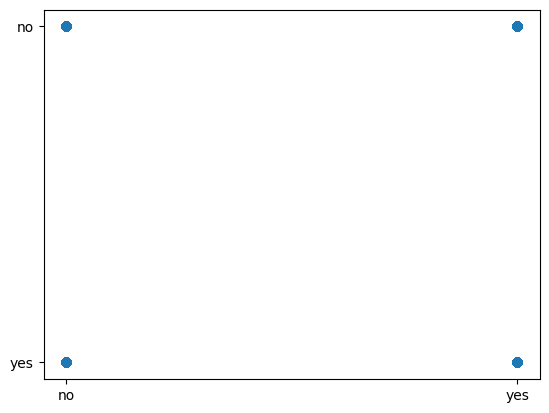

In [8]:
plt.scatter(x="loan",y="deposit",data=df)
plt.show()

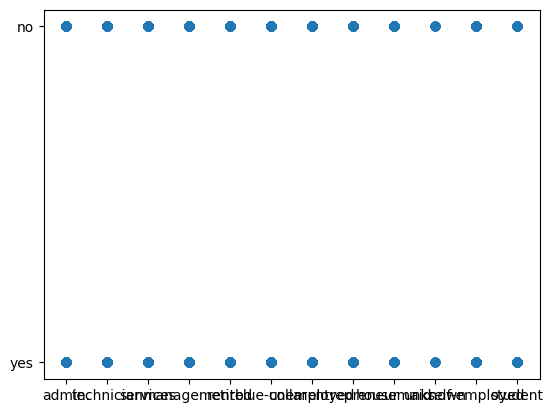

In [9]:
plt.scatter(x="job",y="deposit",data=df)
plt.show()

In [10]:
df.drop(["duration","day","month"],axis=1,inplace=True)

In [11]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [12]:
df["deposit"].unique()

array(['yes', 'no'], dtype=object)

In [13]:
df["deposit"]=df["deposit"].map({
    "yes":1,
    "no":0,
})

In [14]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,1,-1,0,unknown,1
1,56,admin.,married,secondary,no,45,no,no,unknown,1,-1,0,unknown,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,1,-1,0,unknown,1
3,55,services,married,secondary,no,2476,yes,no,unknown,1,-1,0,unknown,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,2,-1,0,unknown,1


In [15]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit       int64
dtype: object

In [16]:
Y= df["deposit"]

In [17]:
X = df.drop(columns=["deposit"])

In [18]:
X = pd.get_dummies(X, columns=["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"], drop_first=True)

In [19]:
X.head()

,age,balance,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,1,-1,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
1,56,45,1,-1,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,41,1270,1,-1,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
3,55,2476,1,-1,0,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True
4,54,184,2,-1,0,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [21]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: deposit, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
model = RandomForestClassifier(random_state=42)

In [26]:
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(X_test)

In [28]:
y_pred

array([1, 0, 0, ..., 0, 1, 1], shape=(2233,))

In [31]:
from sklearn.metrics import classification_report, accuracy_score

In [32]:
classification_report(Y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.67      0.74      0.70      1166\n           1       0.68      0.60      0.64      1067\n\n    accuracy                           0.67      2233\n   macro avg       0.68      0.67      0.67      2233\nweighted avg       0.68      0.67      0.67      2233\n'

In [34]:
accuracy_score(Y_test, y_pred)

0.6748768472906403

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr=LogisticRegression(max_iter=1000)

In [40]:
lr.fit(X_train,Y_train)

D:\anaconda summer internship\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
lr_pred=lr.predict(X_test)

In [42]:
lr_accuracy=accuracy_score(Y_test,lr_pred)

In [43]:
lr_accuracy

0.7012987012987013

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
dt=DecisionTreeClassifier(random_state=42)

In [47]:
dt.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
dt_pred=dt.predict(X_test)

In [49]:
dt_pred=accuracy_score(Y_test,dt_pred)

In [50]:
dt_pred

0.6229287953425885